In [1]:
import sys
from pathlib import Path

_root = next(p for p in Path.cwd().resolve().parents if (p / '.git').exists() or (p / 'setup.py').exists())
for _p in (str(_root), str(_root / 'src')):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import scanpy as sc
# import gseapy as gp
from metab_processing.metab_travlr_config import DATA_DIR
from metab_processing.LinearRegression.build_x import add_gene_signature
from metab_processing.LinearRegression.least_squares import (
    fit_gene_betas, subsample_gene_betas, rank_coefficients,
    plot_top_coefficients, plot_beta_histogram)

# dataset = '12362_HS7_ICI-Slice_4'
# dataset = '12362_HS7_ICI-Slice_3'

# dataset = '13473_HS4_UC-Slice_1'

# dataset = '13117_HS2_HC-Slice_2'

# dataset = '13557_HS3_HC-Slice_2'

dataset = '13732_HS5_UC-Slice_4'
ANNOT_COL, CELL_TYPE = '25_06_11_ICI_5K_Coarse_annotations', 'IEC'
METHOD, PENALTY, STANDARDIZE = 'l1', 0.0001, True
N_SUB = 50
LOWER, UPPER = 15, 85

In [2]:
Alexis_path = Path(f'{DATA_DIR}/Alexi_UC_Spliced')
UCS = [str(p) for p in Alexis_path.iterdir() if p.is_dir()]

In [3]:
for uc in UCS:
    try:
        adata = sc.read_h5ad(f'{uc}/LinearRegression/hvgall_x_adata.h5ad')
    except Exception:
        print(uc)

/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13473_HS4_UC-Slice_2
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/12362_HS7_ICI-Slice_1
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13674_HS9_ICI-Slice_1
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13732_HS5_UC-Slice_2
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13557_HS3_HC-Slice_4
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/12362_HS7_ICI-Slice_2
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/9553_HS8_ICI-Slice_1
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/9553_HS8_ICI-Slice_2
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi_UC_Spliced/13114_HS1_HC-Slice_2
/global/scratch/fsa/fc_wagnerlabfca/fosterangus/MetabTravLR/Data/Alexi

In [9]:
def add_subsample_percentiles(betas_df, sub, lower=LOWER, upper=UPPER):
    """Add min/max and lower/upper-percentile subsample-beta columns to betas_df,
    matched by factor (`sub` = n_subsamples x factor DataFrame from subsample_gene_betas)."""
    out = betas_df.copy()
    def stat(fn):
        return [fn(sub[f]) if f in sub.columns else np.nan for f in out['factor']]
    out['min_subsample_beta'] = stat(np.nanmin)
    out['max_subsample_beta'] = stat(np.nanmax)
    out[f'lower_{lower}_subsample_beta'] = stat(lambda s: np.nanpercentile(s, lower))
    out[f'upper_{upper}_subsample_beta'] = stat(lambda s: np.nanpercentile(s, upper))
    return out

In [10]:
adata = sc.read_h5ad(f'{DATA_DIR}/Alexi_UC_Spliced/{dataset}/LinearRegression/hvgall_x_adata.h5ad')
var = set(adata.var_names)
print(adata.n_obs, 'cells |', len(adata.uns['x_genes']), 'built genes')

3393 cells | 4736 built genes


In [11]:
for gene in ['LGR5', 'CXCL1', 'CXCL8', 'CIITA', 'MUC2', 'SPINK4', 'MMP10', 'MMP1', 'DUOX2', 'DUOXA2', 'REG1A', 'REG3A']:
    if gene not in adata.var.index:
        print(f'{gene} not in data')

CXCL1 not in data
CXCL8 not in data
MMP10 not in data
REG1A not in data
REG3A not in data


In [12]:
# betas = fit_gene_betas(adata, genes=['MMP1', 'DUOX2', 'DUOXA2'], annot_col=ANNOT_COL, annot_value=CELL_TYPE,
#                        method='l1', penalty=PENALTY, standardize=STANDARDIZE)
betas = fit_gene_betas(adata, genes=['DUOX2'], annot_col=ANNOT_COL, annot_value=CELL_TYPE,
                       method='l1', penalty=PENALTY, standardize=STANDARDIZE)

In [13]:
sub = subsample_gene_betas(adata, gene='DUOX2', factors=None, n_subsamples=N_SUB,
                               annot_col=ANNOT_COL, annot_value=CELL_TYPE,
                               method=METHOD, penalty=PENALTY, standardize=STANDARDIZE)
res = add_subsample_percentiles(rank_coefficients(betas), sub, LOWER, UPPER)

/global/home/users/fosterangus/.conda/envs/spacetravlr/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.166378e-02, tolerance: 3.828e-04
  model = cd_fast.enet_coordinate_descent(
/global/home/users/fosterangus/.conda/envs/spacetravlr/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.604384e-01, tolerance: 5.255e-04
  model = cd_fast.enet_coordinate_descent(
/global/home/users/fosterangus/.conda/envs/spacetravlr/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase 

In [15]:
res.head(60)

,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
632,DUOX2,JAM2$JAM2,lr,0.018503,0.107712,0.011602,0.586498,1949,-0.000444,0.048724,-0.000072,3.642112e-02
504,DUOX2,THBS2$ITGAV,lr,0.015037,0.352918,0.124551,0.586498,1949,0.000000,0.027263,0.000000,2.092026e-02
672,DUOX2,JAG1$NOTCH4,lr,0.014892,0.341581,0.116677,0.586498,1949,-0.000647,0.031123,0.000000,2.186594e-02
629,DUOX2,F11R$JAM2,lr,-0.014016,-0.003514,0.000012,0.586498,1949,-0.050375,0.000380,-0.023380,0.000000e+00
445,DUOX2,INSL3$RXFP1,lr,0.011468,0.252003,0.063506,0.586498,1949,-0.000028,0.027792,0.000000,1.998079e-02
593,DUOX2,CDH2$CDH2,lr,0.007438,0.130268,0.016970,0.586498,1949,-0.000163,0.036693,0.000000,1.201013e-02
303,DUOX2,IL37$IL18RAP,lr,0.005675,0.217393,0.047260,0.586498,1949,-0.000036,0.023979,0.000000,1.318092e-02
446,DUOX2,LEP$LEPR,lr,0.005335,0.221768,0.049181,0.586498,1949,-0.001294,0.026585,0.000000,7.885861e-03
153,DUOX2,FGF1$FGFR2,lr,0.005273,0.141551,0.020037,0.586498,1949,-0.000308,0.014025,0.000000,8.729201e-03
19,DUOX2,NHLH2,tf,0.005242,0.184594,0.034075,0.586498,1949,-0.002491,0.004833,0.000000,2.413961e-03


In [36]:
res.iloc[100:150]

,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
13,DUOX2,MSC,tf,-0.000832,-0.002911,0.000008,0.586498,1949,-0.011570,0.000141,-8.806498e-04,0.000000
92,DUOX2,BMP8A$BMPR1A,lr,0.000817,-0.008600,0.000074,0.586498,1949,-0.002182,0.002486,0.000000e+00,0.001136
61,DUOX2,BMP2$BMPR2,lr,-0.000810,-0.009679,0.000094,0.586498,1949,-0.001304,-0.000000,-5.060303e-04,-0.000000
138,DUOX2,WNT2$LRP6,lr,-0.000810,-0.009122,0.000083,0.586498,1949,-0.003075,0.000131,-9.172064e-04,-0.000000
58,DUOX2,TGFB3$ACVR1,lr,0.000809,-0.003402,0.000012,0.586498,1949,-0.002365,0.007858,0.000000e+00,0.000760
430,DUOX2,SEMA3D$NRP2,lr,-0.000801,-0.002072,0.000004,0.586498,1949,-0.019591,0.002062,-1.818095e-03,0.000133
423,DUOX2,HGF$MET,lr,-0.000789,-0.005015,0.000025,0.586498,1949,-0.001757,0.000330,-9.073824e-04,0.000010
674,DUOX2,OCLN$OCLN,lr,-0.000786,0.009280,0.000086,0.586498,1949,-0.002352,0.000244,-1.083984e-03,-0.000004
754,DUOX2,IL22#NHLH2,ltf,0.000784,0.111564,0.012447,0.586498,1949,-0.004036,0.036647,-1.018288e-03,0.007671
169,DUOX2,FGF9$FGFR2,lr,-0.000783,0.008593,0.000074,0.586498,1949,-0.001891,0.001659,-4.085459e-04,0.000195


In [12]:
'INHBA#PRDM1'
'CCL22$CCR4'

'CCL22$CCR4'

In [26]:
betas[betas['factor'] == 'INHBA#PRDM1']

,gene,factor,group,beta,r,r2,model_r2,n_cells
724,DUOX2,INHBA#PRDM1,ltf,-0.018837,0.031698,0.001005,0.680797,1271


In [32]:
res[res['factor'] == 'CCL22$CCR4']

,gene,factor,group,beta,r,r2,model_r2,n_cells,min_subsample_beta,max_subsample_beta,lower_15_subsample_beta,upper_85_subsample_beta
225,DUOX2,CCL22$CCR4,lr,-0.000684,-0.001455,0.000002,0.586498,1949,-0.003461,0.000251,-2.037538e-10,0.0


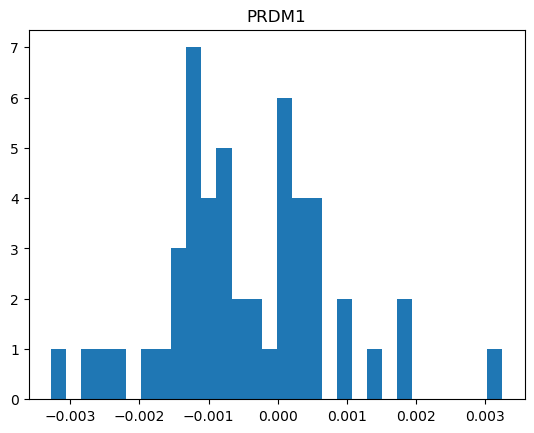

In [58]:
FACTOR = 'PRDM1'
plot_beta_histogram(sub[FACTOR], title=FACTOR);